# PROJE: Ev fiyatı tahmini

#### Kütüphaneler

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#### Yapay veri oluştur

In [90]:
# metrekare (50 - 200 arası)
x = torch.unsqueeze(torch.linspace(50, 200, 100), dim=1)

# fiyat (basit formül + biraz noise)
y = 3 * x + 20 + torch.randn(x.size()) * 10

#### Model

In [91]:
model = nn.Linear(1, 1)

#### Loss + Optimizer

In [92]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

#### Training + loss kaydet

In [93]:
loss_list = []

for epoch in range(400):

    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())

    if epoch % 20 == 0:
        print(loss.item())

144611.5625
17177.345703125
265.6527099609375
496.1913757324219
157.47093200683594
157.35165405273438
153.70565795898438
153.07325744628906
152.93972778320312
152.7819366455078
152.6214141845703
152.45425415039062
152.2792510986328
152.09690856933594
151.90768432617188
151.7119903564453
151.50978088378906
151.3017120361328
151.08775329589844
150.86839294433594


#### Loss grafiği

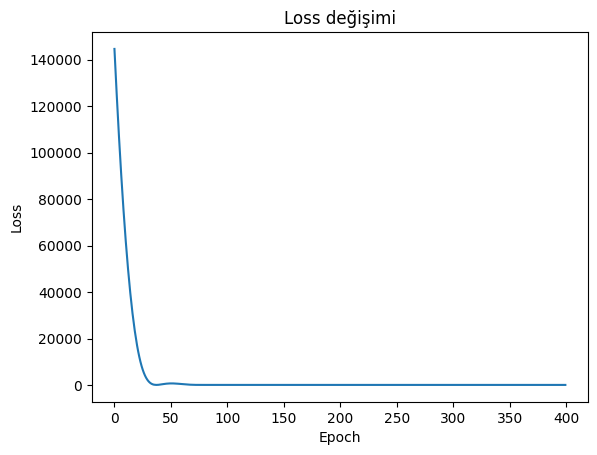

In [94]:
plt.plot(loss_list)
plt.title("Loss değişimi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

#### Tahmin grafiği

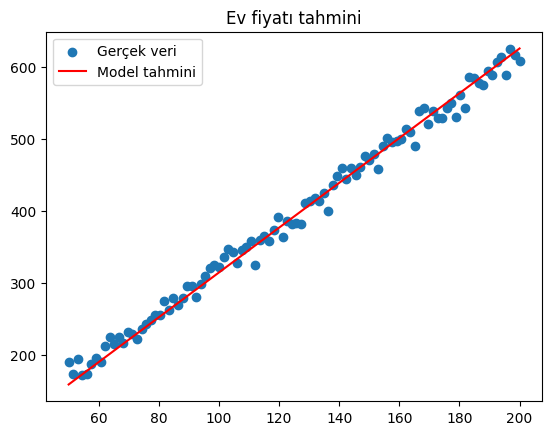

In [95]:
y_pred = model(x).detach().numpy()

plt.scatter(x.numpy(), y.numpy(), label="Gerçek veri")
plt.plot(x.numpy(), y_pred, color='red', label="Model tahmini")

plt.legend()
plt.title("Ev fiyatı tahmini")
plt.show()

#### Model ne öğrendi?

In [96]:
for name, param in model.named_parameters():
    print(name, param.data)

weight tensor([[3.1164]])
bias tensor([2.6997])
